In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout,Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns


In [3]:
from sklearn.datasets import make_circles
X,y=make_circles(n_samples=100,noise=0.1,random_state=1)

<Axes: >

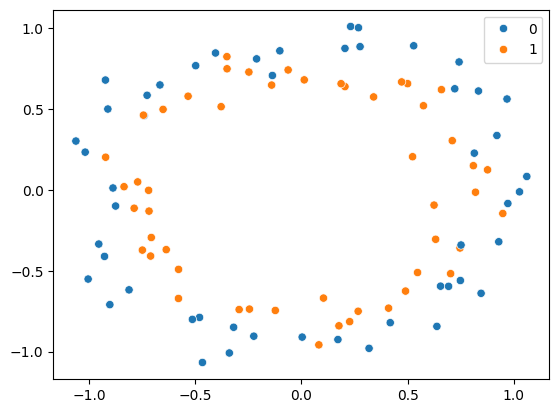

In [4]:

sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [6]:
model=Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-31 13:58:32.712434: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=500,verbose=1)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.9336 - loss: 0.1685 - val_accuracy: 0.6000 - val_loss: 0.9331
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9375 - loss: 0.1649 - val_accuracy: 0.6000 - val_loss: 0.9331
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9375 - loss: 0.1605 - val_accuracy: 0.6500 - val_loss: 0.9341
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9375 - loss: 0.1630 - val_accuracy: 0.6500 - val_loss: 0.9385
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9273 - loss: 0.1491 - val_accuracy: 0.6500 - val_loss: 0.9397
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9250 - loss: 0.1488 - val_accuracy: 0.6500 - val_loss: 0.9390
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9352 - loss: 0.1648 - val_accuracy: 0.6500 - val_loss: 0.9390
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9375 - loss: 0.1790 - val_accuracy: 0.6000 - val_loss

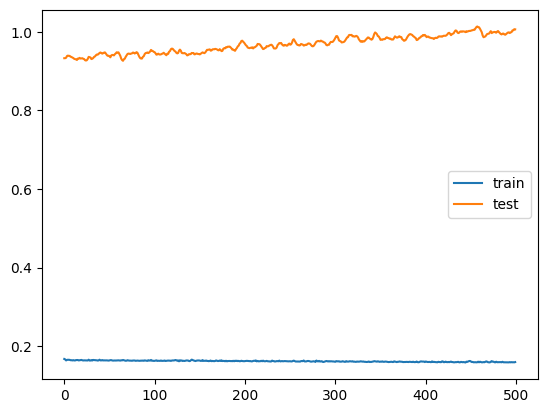

In [9]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


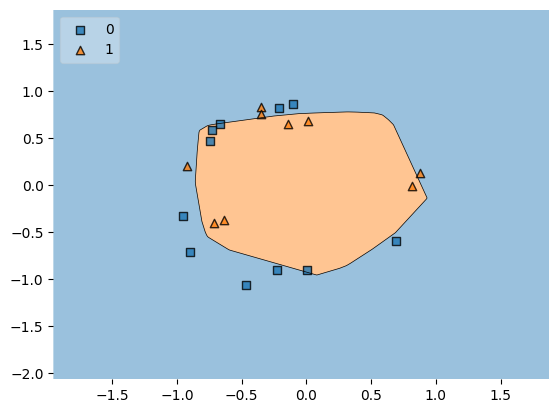

In [10]:
plot_decision_regions(X_test,y_test.ravel(),clf=model,legend=2)
plt.show()

In [11]:
#early stopping
model=Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [12]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])


In [17]:
callback=EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
    
)
# 🔍 Meaning of Each Parameter
# 1. monitor='val_loss'
# What to track during training
# Here: validation loss
# Training stops when this stops improving

# 👉 Alternatives:

# 'loss' → training loss
# 'val_accuracy' → validation accuracy
# 2. min_delta=0.00001
# Minimum improvement required to count as progress

# 👉 Meaning:

# If improvement is less than 0.00001, it is ignored

# ✔ Example:

# Old val_loss = 0.50000
# New val_loss = 0.49999
# → Improvement = 0.00001 ✅ (counts)
# New val_loss = 0.499995
# → Improvement too small ❌ (ignored)
# 3. patience=20
# How many epochs to wait after no improvement

# 👉 Meaning:

# If val_loss doesn’t improve for 20 epochs, stop training

# ✔ Example:

# Epoch 10 → last improvement
# Epoch 30 → still no improvement
# → Training stops at epoch 30
# 4. verbose=1
# Controls printing messages

# 👉 Values:

# 0 → no output
# 1 → shows message when stopping

# ✔ Example output:

# Epoch 45: early stopping
# 5. mode='auto'
# Decides whether to minimize or maximize

# 👉 Behavior:

# 'val_loss' → minimize
# 'accuracy' → maximize

# ✔ You can also set manually:

# 'min' → for loss
# 'max' → for accuracy
# 6. baseline=None
# Minimum performance required to continue training

# 👉 Meaning:

# Training will stop if model never reaches this value

# ✔ Example:

# baseline=0.5
# If val_loss never goes below 0.5 → stop early
# 7. restore_best_weights=False
# Whether to restore best model weights

# 👉 Meaning:

# False → keep last epoch weights
# True → restore best val_loss weights

# ✔ Best practice:

# restore_best_weights=True

# 👉 Because last epoch is often worse (overfitting)

In [14]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=3500,callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.5273 - loss: 0.6904 - val_accuracy: 0.4500 - val_loss: 0.7045
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4922 - loss: 0.6889 - val_accuracy: 0.3500 - val_loss: 0.7068
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5516 - loss: 0.6866 - val_accuracy: 0.3500 - val_loss: 0.7082
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4828 - loss: 0.6855 - val_accuracy: 0.3500 - val_loss: 0.7105
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5344 - loss: 0.6845 - val_accuracy: 0.4000 - val_loss: 0.7117
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5602 - loss: 0.6838 - val_accuracy: 0.4000 - val_loss: 0.7132
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5688 - loss: 0.6873 - val_accuracy: 0.4500 - val_loss: 0.7138
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5664 - loss: 0.6864 - val_accuracy: 0.4000 - 

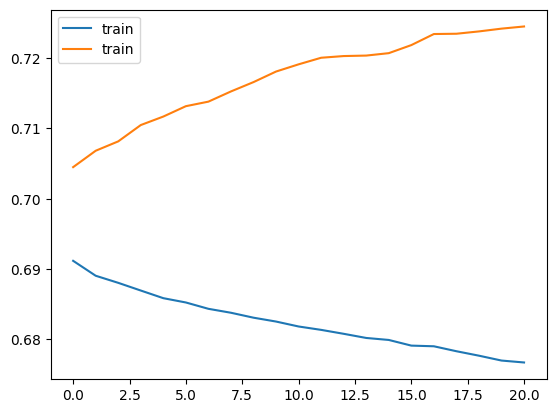

In [15]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='train')
plt.legend()
plt.show()